EX 4

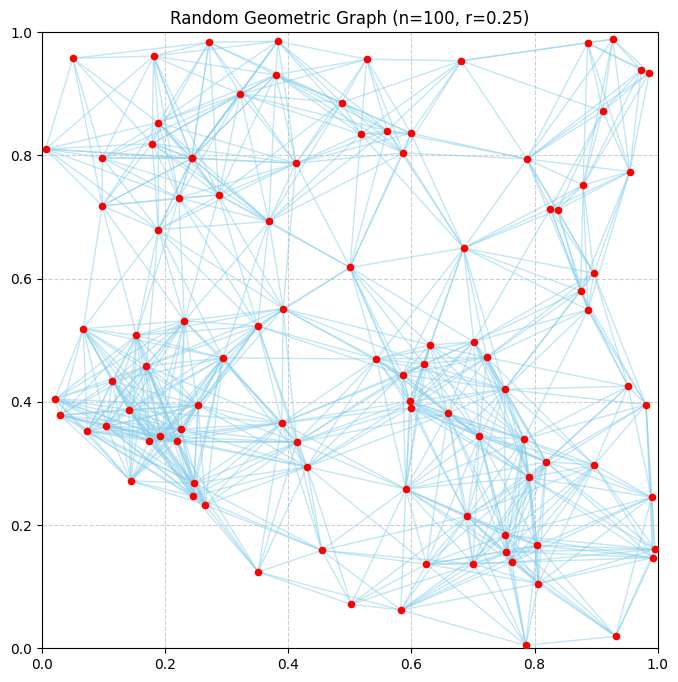

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

n_points = 100
threshold = 0.25


coords = np.random.uniform(0, 1, size=(n_points, 2))


dist_matrix = squareform(pdist(coords))

A = (dist_matrix <= threshold) & (dist_matrix > 0)
degrees = np.sum(A, axis=1)
D = np.diag(degrees)
L = D - A

# --- Visualization ---
plt.figure(figsize=(8, 8))
plt.scatter(coords[:, 0], coords[:, 1], color='red', zorder=5, s=20)

# Plot the edges
for i in range(n_points):
    for j in range(i + 1, n_points):
        if A[i, j]:
            x_values = [coords[i, 0], coords[j, 0]]
            y_values = [coords[i, 1], coords[j, 1]]
            plt.plot(x_values, y_values, color='skyblue', alpha=0.5, lw=1)

plt.title(f"Random Geometric Graph (n=100, r={threshold})")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [12]:
np.set_printoptions(precision=4, suppress=True)
eigval,eigvec = np.linalg.eig(L)
eigvec = eigvec.T
indexed_sorted = sorted(enumerate(eigval), key=lambda x: x[1])

# print(eigvec[0])
print(eigval)

[-0.      0.9927  1.1014  1.9341  4.3071  4.7249  5.9483  6.7604 27.2859
  7.483  26.3112 26.1185  8.1894  8.2816  9.3892  9.3977 25.5904  9.7432
 25.5339 25.3564 25.1408  8.      9.9908 10.4535 10.7652 10.8089 24.7715
  9.     24.4793 24.5163 24.1794 11.4544 11.7355 12.0611 23.7361 12.2398
 23.625  23.5616 12.4143 12.5596 22.9041 22.7275 12.7126 12.8062 13.0949
 13.4299 22.5346 24.     22.4292 13.5435 13.5744 13.7993 13.8508 14.1046
 15.147  14.8464 14.674  14.5905 14.3395 21.6761 21.6134 15.489  21.4923
 21.2162 15.9103 16.1654 20.8491 16.5759 20.7549 16.8007 20.6413 20.5326
 20.3158 20.2257 17.1162 19.4382 19.1796 18.7976 18.2619 18.235  18.5849
 17.3871 19.6243 17.9377 20.0143 17.6388 18.647  17.7378 17.2283 19.8747
 19.7834 17.5642 17.8143 19.8244 13.     14.     17.     20.     20.
 20.    ]


In [35]:
mask = (coords[:, 0] < 0.5) & (coords[:, 1] < 0.5)
keep = np.where(mask)[0]
print(keep)


[ 0  8 13 21 25 27 28 32 35 36 43 51 53 66 72 80 85 86 88 94 97 99]


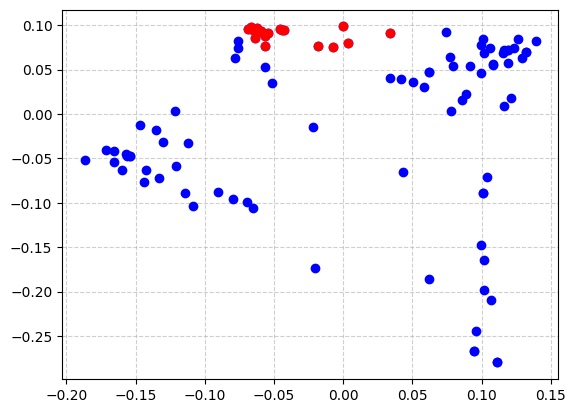

In [36]:
# print(eigvec[indexed_sorted[1][0]],eigvec[indexed_sorted[2][0]])
# plt.plot(eigvec[indexed_sorted[1][0]],eigvec[indexed_sorted[2][0]], marker='o', linestyle='-', color='b', label='Vector Data')
x_val = eigvec[indexed_sorted[1][0]]
y_val = eigvec[indexed_sorted[2][0]]


plt.plot(x_val,y_val, color="blue",marker='o',linestyle='none')
plt.plot(x_val[keep],y_val[keep], color="red",marker='o',linestyle='none')



plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

since the points in the bottom quarter are all close and the second/third eigvectors try to keep everything close in value, they appear clustered together in the spectral embedding